In [2]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression as LOR
from sklearn.model_selection import KFold
from generalized_contrastive_PCA import gcPCA
from scipy.stats import median_abs_deviation as MAD

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

## Define Helpers and Functions

In [3]:
def reject_outliers(X, m=3, scaling=False):
    """
    Adapted from https://medium.com/@saraswatp/exploring-data-anomalies-rejecting-outliers-with-python-660b1ed6bca6
    Returns a boolean mask where True = 'Keep' and False = 'Outlier'.
    """
    median = np.median(X, axis=0)
    # mad = MAD(X, axis=0, scale='normal')

    if scaling:
        mad = np.median(np.abs(X - median), axis=0) * 1.4826
    else:
        mad = np.median(np.abs(X - median), axis=0)
    
    upper_bound = median + m * mad
    lower_bound = median - m * mad

    mask = (X >= lower_bound) & (X <= upper_bound)

    return mask


def reject_outliers_by_subject_channel(burst_dict, value_key='peak_amp_base', m=3, scaling=False):
    """Compute outlier mask separately within each subject x chennel group.

    Args:
        burst_dict (dictionary): Burst dictionary containing at least:
            - 'subject'
            - 'channel'
            - value_key
        
        value_key (str, optional): Name of the feature on which to reject outliers. Defaults to 'peak_amp_base'.
        m (float, optional): Number of MADs from the median used as the cutoff. Defaults to 3.
        scaling (bool, optional): If True, scale MAD by 1.4826. Defaults to False.
    
    Returns:
        group_mask: ndarray of bool, shape (n_bursts,). Global mask with True = keep, False = outlier.
    """

    values = np.asarray(burst_dict[value_key])
    subjects_arr = np.asarray(burst_dict['subject'])
    channels_arr = np.asarray(burst_dict['channel'])

    n = len(values)
    if not (len(subjects_arr) == n and len(channels_arr) == n):
        raise ValueError(f"'subject', 'channel', and '{value_key}' must have the same length." )
    
    group_mask = np.ones(n, dtype=bool)
    unique_subjects = np.unique(subjects_arr)

    for sub in unique_subjects:
        sub_idx = subjects_arr == sub
        sub_channels = np.unique(channels_arr[sub_idx])

        for ch in sub_channels:
            idx = sub_idx & (channels_arr == ch)

            # Reject within this subject x channel subset
            local_mask = reject_outliers(values[idx], m=m, scaling=scaling)

            # Write local decisions back into full-length mask
            group_mask[idx] = local_mask

    return group_mask

In [4]:
def scaler_fit(X):
    median = np.median(X, axis=0)
    mad = MAD(X, axis=0, scale='normal')
    return median, mad


def scaler_transform(X, median, mad):
    return (X - median) / mad

In [5]:
def get_features_and_labels(gcPC_scores, bursts_dict, type_subs, cols_idx, n_bins, area):
    """
    Function to build the feature matrix and label vector for the logistic regression classifier.
    It takes as input the gcPC scores for all bursts, the bursts dictionary, the indices of the gcPCs
    to consider, the number of bins to use for each gcPC, the number of MADs to use for outlier
    rejection when building trial-level features, and the area to consider (STN or cortical).
    """
    
    max_type_subs = sum(len(np.unique(bursts_dict['trial'][bursts_dict['subject'] == sub])) for sub in type_subs)
    X = np.zeros((max_type_subs, len(cols_idx) * n_bins))
    y = np.zeros(max_type_subs)

    r = 0
    for i in range(len(type_subs)):
        type_sub = type_subs[i]
        
        # compute percentile bin limits using subject bursts only
        subject_bursts_idx = (bursts_dict['subject'] == type_sub) & area
        if np.sum(subject_bursts_idx) == 0:
            print(f'Warning: No bursts found for subject {type_sub} in the selected area ({area}). '
                  'Skipping this subject for percentile bin limit computation.')
            continue

        pc_bin_lims = np.zeros((len(cols_idx), n_bins + 1))
        for col_idx, col in enumerate(cols_idx):
            pc_bin_lims[col_idx, :] = np.percentile(gcPC_scores[subject_bursts_idx, col], np.linspace(0, 100, n_bins + 1))

        # Build trial-level features across all cortex trials
        trials = np.unique(bursts_dict['trial'][(bursts_dict['subject'] == type_sub)])
        for trial in trials:
            burst_idx = area & (bursts_dict['trial'] == trial) & (bursts_dict['subject'] == type_sub)
            label = np.unique(bursts_dict['med'][burst_idx])[0]
            
            row = np.zeros(len(cols_idx) * n_bins, dtype=float)  # Pre-allocate row with zeros for gcPC-bin combinations with no bursts
            for col_idx, col in enumerate(cols_idx):
                for bin in range(n_bins):
                    lower = pc_bin_lims[col_idx, bin]
                    higher = pc_bin_lims[col_idx, bin+1]
                    count = np.sum((gcPC_scores[burst_idx, col] >= lower) &
                                    (gcPC_scores[burst_idx, col] < higher))
                    row[col_idx * n_bins + bin] = count
            X[r, :] = row
            y[r] = 0 if label == 'OFF' else 1
            r += 1

    X = X[:r]
    y = y[:r]

    return X, y

## Data loading

### Channel labels

In [6]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

### Subject labels

In [7]:
data_dir = '../../data/preprocessed_data/'
out_path = '../../data/derivatives/'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


### Aggregating burst features of the STN and of motor cortex (C3,C4) across all subjects

In [8]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


## Perform light pre-processing
* Redefine the trial indices ensuring they're not overlapping between ON and OFF medication - subject-level based
* Convert burst time to ms
* Reject burst outliers based on their peak amplitude

In [9]:
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject)
    off_med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']=='OFF')])
    max_off_trial = np.max(off_med_trials)
    on_med_idx = subj_idx & (all_bursts['med']=='ON')
    all_bursts['trial'][on_med_idx] = all_bursts['trial'][on_med_idx] + max_off_trial + 1 

In [10]:
burst_times = all_bursts['waveform_times'] * 1000 

In [16]:
outlier_mask = reject_outliers_by_subject_channel(
    all_bursts,
    value_key='peak_amp_base',
    m=3,
    scaling=False
    )

len_mask = len(outlier_mask)

correct_bursts = {
    key: (value[outlier_mask] if len(value) == len_mask else value)
    for key, value in all_bursts.items()
    }

# print(f"Original trials: {len(all_bursts['peak_amp_base'])}")
# print(f"Corrected trials: {len(correct_bursts['peak_amp_base'])}")
# print(f"Removed trials: {len(all_bursts['peak_amp_base']) - len(correct_bursts['peak_amp_base'])}")

### Select bursts corresponding to C3/C4 and all STN contacts

In [17]:
c_idx = (correct_bursts['channel']=='C3') | (correct_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in correct_bursts['channel']]

### Plot the beta burst waveform for sensorimotor cortex (C3,C4) Vs STN 

In [18]:
on_idx = (correct_bursts['med']=='ON')
off_idx = (correct_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [19]:
"""
```scaling_method``` accepts: 
    - 'MAD-based',
    - 'Robust',
    - 'Standard'
"""
scaling_method = 'Robust'

area = stn_idx
scaled_waveforms = np.zeros_like(correct_bursts['waveform'])
for subject in np.unique(correct_bursts['subject']):
    subj_idx = (correct_bursts['subject'] == subject)

    if scaling_method == 'Robust':
        """Perform a modified z-score based on median and IQR"""
        scaler = RobustScaler().fit(correct_bursts['waveform'][subj_idx & area])                # .fit() returns the median and IQR values
        scaled_waveforms[subj_idx, :] = scaler.transform(correct_bursts['waveform'][subj_idx])  # .transform() does the maths.

    elif scaling_method == 'Standard':
        """Perform a z-score based on mean and STD"""
        scaler = StandardScaler().fit(correct_bursts['waveform'][subj_idx & area])              # .fit() returns the mean and STD values
        scaled_waveforms[subj_idx, :] = scaler.transform(correct_bursts['waveform'][subj_idx])  # .transform() does the maths.

    elif scaling_method == 'MAD-based':
        """Perfom a modified z-score based on median and MAD"""
        median, mad = scaler_fit(correct_bursts['waveform'][subj_idx & area])                   # Scaler based on MAD
        scaled_waveforms[subj_idx, :] = scaler_transform(correct_bursts['waveform'][subj_idx], median, mad)

    else:
        raise AttributeError("Wrong scaling method. Valide options are ['MAD-based', 'Robust', 'Standard'].")

## Perform a gcPCA and scores, coefficients, intercept are saved at the fold-level

### Group-level cross validation: split subjects into train/test groups
* 1/ Perfom a gcPCA
* 2/ Each PC is binned
* 3/ Compute logit on the gcPCA, taking number of PCs and bins as features

In [24]:
"""Parameters definition"""
n_bins = 4                          # Number of bins to use for each gcPC
n_gcPCs = np.arange(0, 10, 1)       # Half number of gcPCs to consider
area = c_idx

subjects = np.array(subjects)
n_splits = len(subjects)
kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)

accuracy = []
var = []
for n_gcPC in n_gcPCs+1:
    null_and_positive = np.arange(0, n_gcPC + 1, 1)
    negative = np.arange(-n_gcPC - 1, 0, 1)
    cols = np.concatenate([null_and_positive, negative])
    print(cols)

    fold_scores = []
    for fold_idx, (train_s_idx, test_s_idx) in enumerate(kf.split(subjects)):
        train_subs = subjects[train_s_idx]
        test_subs = subjects[test_s_idx]

        # select bursts from training subjects (cortex channels only)
        train_bursts_idx = np.isin(correct_bursts['subject'], train_subs) & area
        train_bursts_on_idx = train_bursts_idx & (correct_bursts['med']=='ON')
        train_bursts_off_idx = train_bursts_idx & (correct_bursts['med']=='OFF')

        # Fit gcPCA on training subjects' bursts
        gcpca_model = gcPCA(method='v4', normalize_flag=False)
        gcpca_model.fit(scaled_waveforms[train_bursts_off_idx, :], scaled_waveforms[train_bursts_on_idx, :])
        all_scores = scaled_waveforms @ gcpca_model.loadings_
        
        X_train, y_train = get_features_and_labels(all_scores, correct_bursts, train_subs, cols, n_bins, area)
        X_test, y_test = get_features_and_labels(all_scores, correct_bursts, test_subs, cols, n_bins, area)

        X_train = np.array(X_train)
        X_test = np.array(X_test)
        y_train = np.array(y_train)
        y_test = np.array(y_test)

        model = LOR(max_iter=10_000)
        model = model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        intercept = model.intercept_
        coefs = model.coef_

        score = np.mean(y_test == y_pred)
        print(f'Fold {fold_idx}: Score = {score:.3f}')
        # print('  train_subs:', train_subs)
        # print('  test_subs:', test_subs)
        # print(f'  X_train shape: {X_train.shape}')
        # print(f'  X_test shape: {X_test.shape}\n')
        fold_scores.append(score)

    print(f'Group-level CV: Mean Score = {np.mean(fold_scores):.3f} ± {np.std(fold_scores):.3f}')
    accuracy.append(np.mean(fold_scores))
    var.append(np.std(fold_scores))
    print(n_gcPC)
    print("\n")

[ 0  1 -2 -1]
Fold 0: Score = 0.512
Fold 1: Score = 1.000
Fold 2: Score = 0.947
Fold 3: Score = 0.526
Fold 4: Score = 0.667
Fold 5: Score = 0.474
Fold 6: Score = 0.514
Fold 7: Score = 0.378
Fold 8: Score = 0.525
Fold 9: Score = 1.000
Fold 10: Score = 0.879
Group-level CV: Mean Score = 0.675 ± 0.224
1


[ 0  1  2 -3 -2 -1]
Fold 0: Score = 0.561
Fold 1: Score = 1.000
Fold 2: Score = 0.921
Fold 3: Score = 0.553
Fold 4: Score = 0.667
Fold 5: Score = 0.553
Fold 6: Score = 0.514
Fold 7: Score = 0.405
Fold 8: Score = 0.500
Fold 9: Score = 1.000
Fold 10: Score = 0.848
Group-level CV: Mean Score = 0.684 ± 0.207
2


[ 0  1  2  3 -4 -3 -2 -1]
Fold 0: Score = 0.659
Fold 1: Score = 1.000
Fold 2: Score = 0.842
Fold 3: Score = 0.605
Fold 4: Score = 0.667
Fold 5: Score = 0.579
Fold 6: Score = 0.568
Fold 7: Score = 0.486
Fold 8: Score = 0.500
Fold 9: Score = 1.000
Fold 10: Score = 0.879
Group-level CV: Mean Score = 0.708 ± 0.181
3


[ 0  1  2  3  4 -5 -4 -3 -2 -1]
Fold 0: Score = 0.585
Fold 1: Score = 

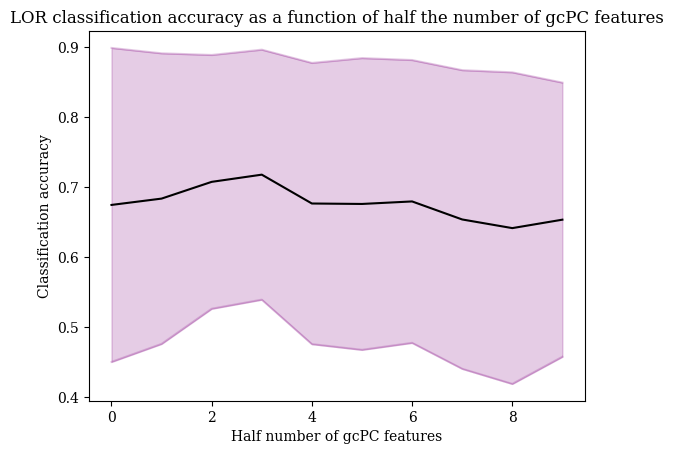

In [25]:
upper = np.array(accuracy) + np.array(var)
lower = np.array(accuracy) - np.array(var)

plt.plot(accuracy, color='black')
plt.plot(upper, color='purple', alpha=0.2)
plt.plot(lower, color='purple',alpha=0.2)
plt.fill_between(range(len(accuracy)), lower, upper, color='purple', alpha=0.2)
plt.xlabel('Half number of gcPC features')
plt.ylabel('Classification accuracy')
plt.title('LOR classification accuracy as a function of half the number of gcPC features')
plt.show()

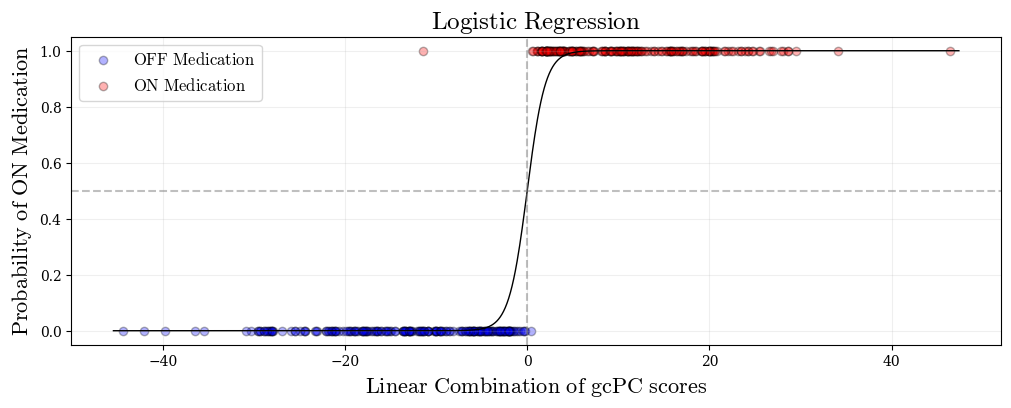

In [26]:
X = np.vstack([X_train, X_test])
y = np.hstack([y_train, y_test])
z = intercept + (X @ coefs.ravel())
z_range = np.linspace(np.min(z) - 1, np.max(z) + 1, 1000)
p_range = 1 / (1 + np.exp(-z_range))
plt.figure(figsize=(12, 4))
plt.plot(z_range, p_range, color='black', linewidth=1)  # , label=r"$\mathrm{Logistic\ Regression\ Fit}$"
plt.scatter(z[y==0], y[y==0], color='blue', alpha=0.3, label=r"$\mathrm{OFF\ Medication}$", edgecolor='k')
plt.scatter(z[y==1], y[y==1], color='red', alpha=0.3, label=r"$\mathrm{ON\ Medication}$", edgecolor='k')
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.axhline(0.5, color='grey', linestyle='--', alpha=0.5)
plt.title(r"$\mathrm{Logistic\ Regression}$", fontsize=18)
plt.xlabel(r"$\mathrm{Linear\ Combination\ of\ gcPC\ scores}$", fontsize=16)
plt.ylabel(r"$\mathrm{Probability\ of\ ON\ Medication}$", fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.2)
plt.show()